# 04 – Systematic Error Analysis

**Purpose:** Perform a deep diagnostic analysis of the errors made by our best baseline classifier (`Linear SVM`) on the Banking77 customer support test split.

This notebook covers:
1. Loading prediction and misclassification datasets.
2. Finding the top 100 mistakes.
3. Identifying per-class accuracies and identifying the hardest classes.
4. Showcasing longest and shortest failures.
5. Listing the most frequently confused intent pairs.
6. Rendering and displaying a confusion matrix heatmap zoomed into the top error classes.

## 0. Setup and Environment

In [1]:
import sys
from pathlib import Path
import pandas as pd
import IPython.display as display

REPO_ROOT = Path().resolve().parent
if REPO_ROOT.name != "SupportAI" and (REPO_ROOT / "SupportAI").exists():
    REPO_ROOT = REPO_ROOT / "SupportAI"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.error_analysis import ErrorAnalyzer
from src.utils.constants import OUTPUT_DIR

predictions_path = OUTPUT_DIR / "metrics" / "predictions.csv"
model_name = "linear_svm"

analyzer = ErrorAnalyzer(predictions_path, model_name)
summary = analyzer.run_analysis_pipeline()
print("Error analysis pipelines executed and outputs exported.")

[07/13/26 09:21:29] INFO     Saving CSV dataset to:                                                                
                             C:\Users\gunav\Downloads\SupportAI\outputs\metrics\misclassified.csv

                    INFO     Saving CSV dataset to:                                                                
                             C:\Users\gunav\Downloads\SupportAI\outputs\metrics\class_metrics.csv

                    INFO     Saving visualization figure to:                                                       
                             C:\Users\gunav\Downloads\SupportAI\outputs\metrics\plots\confusion_heatmap.png

[07/13/26 09:21:32] INFO     Confusion heatmap saved to:                                                           
                             C:\Users\gunav\Downloads\SupportAI\outputs\metrics\plots\confusion_heatmap.png

                    INFO     Error analysis completed for 'linear_svm' | Total Errors: 121

Error analysis pipelines executed and outputs exported.


## 1. Top 100 Mistakes

Let's load the saved misclassified examples CSV and show the first 10 mistakes.

In [2]:
misclassified_df = pd.read_csv(OUTPUT_DIR / "metrics" / "misclassified.csv")
print(f"Total misclassified instances: {len(misclassified_df)}")
print("\nFirst 10 mistakes:")
misclassified_df[["text", "label_text", "pred_label_text"]].head(10)

Total misclassified instances: 121

First 10 mistakes:


,text,label_text,pred_label_text
0,what do i do if my verification failed,unable_to_verify_identity,failed_transfer
1,i wanted to know why my transaction didn't go ...,declined_transfer,failed_transfer
2,"i can't make any transfers, they won't go thro...",declined_transfer,pending_transfer
3,i ordered my card a couple weeks ago and haven...,card_delivery_estimate,card_arrival
4,can i use a transfer to receive my transfer?,receiving_money,beneficiary_not_allowed
5,my topup got reverted. please let me know if t...,top_up_reverted,top_up_failed
6,can you tell me what currency i can have?,fiat_currency_support,supported_cards_and_currencies
7,i was charged when i used a us issued card. wh...,top_up_by_card_charge,supported_cards_and_currencies
8,what are the restrictions to top-offs?,top_up_limits,disposable_card_limits
9,my last atm request did not go through due to ...,pending_cash_withdrawal,declined_cash_withdrawal


## 2. Per-Class Accuracy Analysis

Let's load the class metrics table and view classes with the lowest accuracy (hardest intents to classify).

In [3]:
class_metrics_df = pd.read_csv(OUTPUT_DIR / "metrics" / "class_metrics.csv")
print("Top 10 Hardest Class Intents (Lowest Accuracy):")
class_metrics_df.sort_values("accuracy", ascending=True).head(10)

Top 10 Hardest Class Intents (Lowest Accuracy):


,class_id,precision,recall,f1_score,support,accuracy
5,5,0.714286,0.714286,0.714286,21.0,0.714286
68,68,1.000000,0.714286,0.833333,14.0,0.714286
28,28,1.000000,0.727273,0.842105,22.0,0.727273
59,59,0.823529,0.736842,0.777778,19.0,0.736842
46,46,0.875000,0.736842,0.800000,19.0,0.736842
66,66,0.761905,0.761905,0.761905,21.0,0.761905
27,27,0.866667,0.764706,0.812500,17.0,0.764706
48,48,0.700000,0.777778,0.736842,18.0,0.777778
58,58,1.000000,0.812500,0.896552,16.0,0.812500
74,74,0.812500,0.812500,0.812500,16.0,0.812500


## 3. Longest and Shortest Failures

Reviewing length-based failure modes: queries that are very long (often containing multiple clauses or context) vs. queries that are very short (containing sparse keywords).

In [4]:
longest_fails = analyzer.get_longest_failures(5)
print("Longest Failed Queries:")
for idx, row in longest_fails.iterrows():
    print(f"- Text ({row['text_len_chars']} chars): {row['text']}")
    print(f"  True: {row['label_text']} | Pred: {row['pred_label_text']}\n")

Longest Failed Queries:
- Text (207 chars): wtf??? i tried to withdraw some money at a metro bank on high st. kensington and without any notice it disappeared in the machine. the bank was already closed so i couldn't do anything. how do i get it back?
  True: card_swallowed | Pred: pending_cash_withdrawal

- Text (191 chars): please help! i was looking at my account and saw a transaction with a seller i don't remember. is it possible for you to track the sale, because i really don't think i made a payment to them.
  True: direct_debit_payment_not_recognised | Pred: card_payment_not_recognised

- Text (183 chars): i am having a huge problem with my card being declined and it's really important that i top-up today. would you please look into this further and let me know how i can get this fixed?
  True: top_up_failed | Pred: declined_card_payment

- Text (180 chars): i saw money was taken out of my account by a seller a while back. i do not recognize the seller, but i'm pretty certain i 

In [5]:
shortest_fails = analyzer.get_shortest_failures(5)
print("Shortest Failed Queries:")
for idx, row in shortest_fails.iterrows():
    print(f"- Text ({row['text_len_chars']} chars): {row['text']}")
    print(f"  True: {row['label_text']} | Pred: {row['pred_label_text']}\n")

Shortest Failed Queries:
- Text (17 chars): what is the word?
  True: direct_debit_payment_not_recognised | Pred: exchange_rate

- Text (17 chars): where is my card?
  True: card_arrival | Pred: card_acceptance

- Text (19 chars): are there atm fees?
  True: cash_withdrawal_charge | Pred: atm_support

- Text (20 chars): my transfer isn't in
  True: transfer_not_received_by_recipient | Pred: balance_not_updated_after_bank_transfer

- Text (21 chars): top-up is not working
  True: top_up_failed | Pred: pending_top_up



## 4. Most Confused Intent Pairs

Identify which pairs of class labels are mistranslated the most.

In [6]:
confused_df = analyzer.get_most_confused_intents(10)
print("Top Confused Intent Pairs:")
confused_df

Top Confused Intent Pairs:


,label_text,pred_label_text,confusion_count
89,transfer_not_received_by_recipient,balance_not_updated_after_bank_transfer,4
3,balance_not_updated_after_bank_transfer,pending_transfer,3
4,balance_not_updated_after_bank_transfer,transfer_not_received_by_recipient,2
0,activate_my_card,card_arrival,2
26,compromised_card,lost_or_stolen_card,2
65,pending_transfer,balance_not_updated_after_bank_transfer,2
41,disposable_card_limits,get_disposable_virtual_card,2
13,card_delivery_estimate,card_arrival,2
94,unable_to_verify_identity,why_verify_identity,2
79,top_up_failed,pending_top_up,2


## 5. Confusion Heatmap visualization

Display the rendered confusion matrix heatmap zoom-in plot.

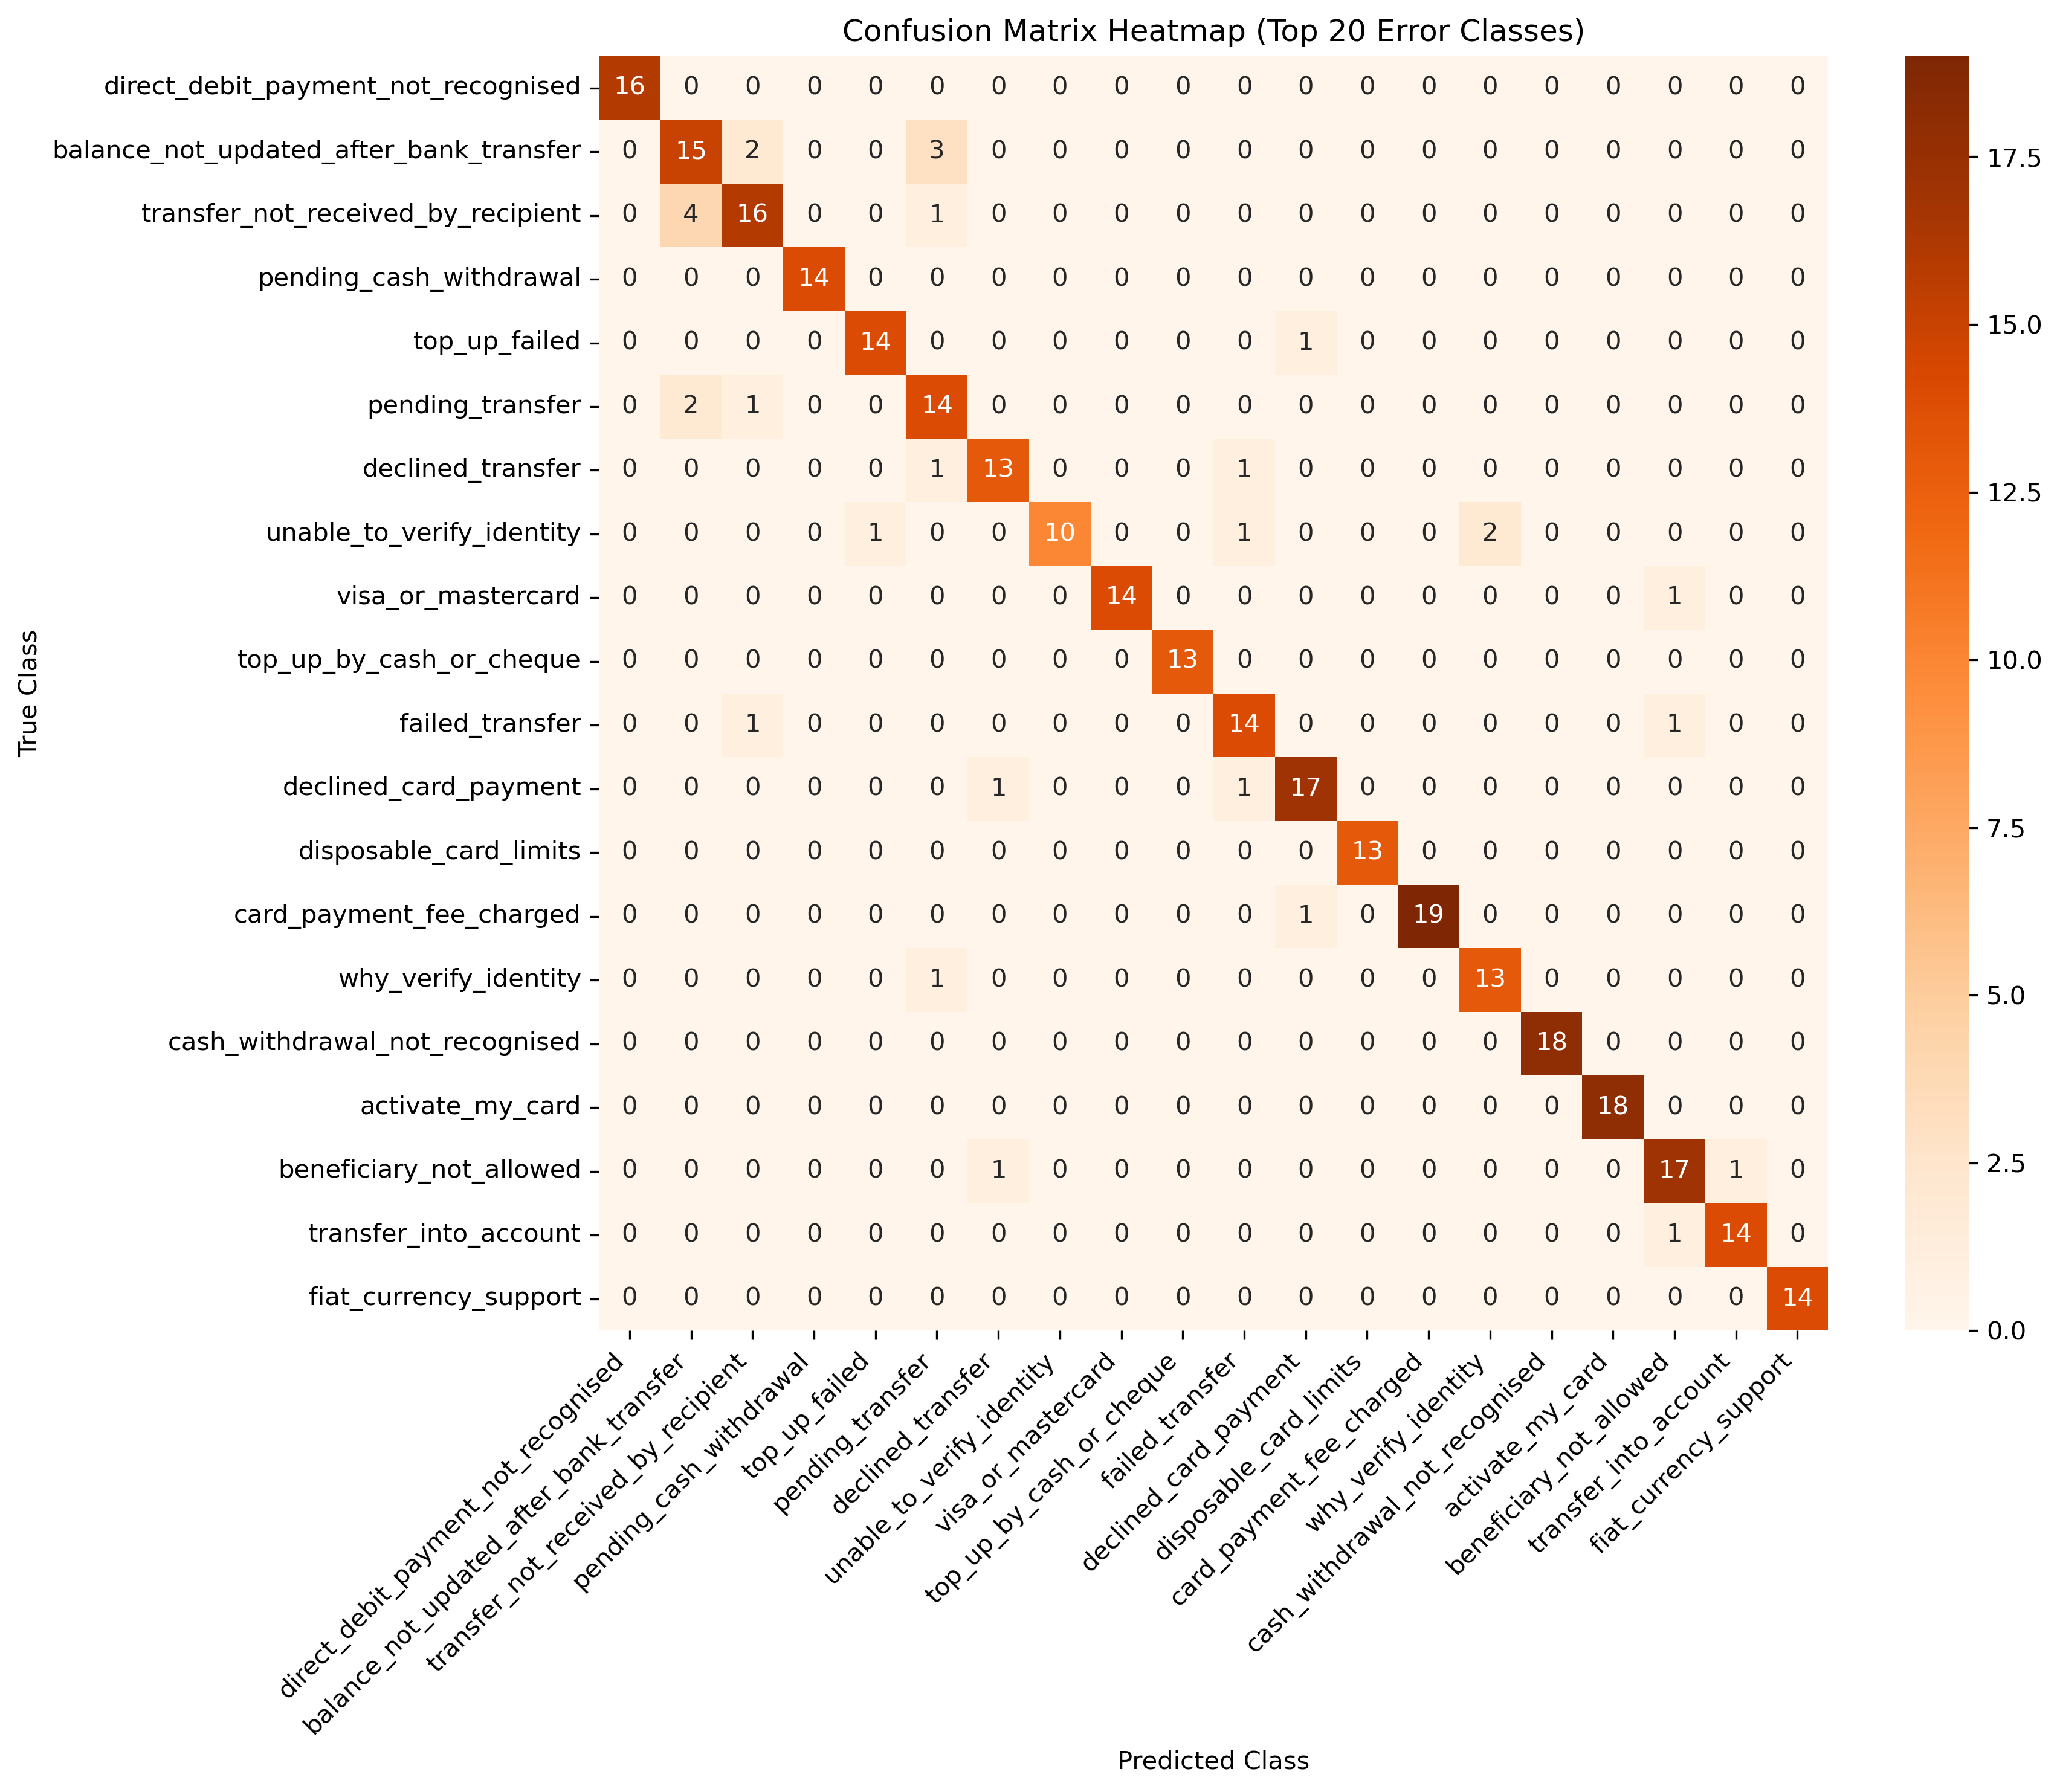

In [7]:
display.Image(filename=str(OUTPUT_DIR / "metrics" / "plots" / "confusion_heatmap.png"))

In [8]:
# Export Phase Manifest
import json
from src.utils.artifacts import save_yaml
from src.api.app import get_git_commit

error_summary_path = REPO_ROOT / "outputs" / "metrics" / "error_summary.json"
error_summary = {}
if error_summary_path.exists():
    with open(error_summary_path) as f:
        error_summary = json.load(f)

manifest = {
    "phase": "04_Error_Analysis",
    "error_summary": error_summary,
    "git_commit": get_git_commit(),
}
save_yaml(manifest, REPO_ROOT / "outputs" / "manifests" / "phase_04_error_analysis.yaml")
print("YAML manifest saved successfully:")
print(manifest)


[07/13/26 09:22:25] INFO     Loading faiss with AVX2 support.

                    INFO     Could not load library with AVX2 support due to:                                      
                             ModuleNotFoundError("No module named 'faiss.swigfaiss_avx2'")

                    INFO     Loading faiss.

                    INFO     Successfully loaded faiss.

[07/13/26 09:22:26] INFO     TensorFlow version 2.20.0 available.

[07/13/26 09:22:28] INFO     Saving YAML artifact to:                                                              
                             C:\Users\gunav\Downloads\SupportAI\outputs\manifests\phase_04_error_analysis.yaml

YAML manifest saved successfully:
{'phase': '04_Error_Analysis', 'error_summary': {}, 'git_commit': 'cc1c1de64b28542d4db316ac79bd4990d31964a5'}
